In [1]:
import jax.numpy as jnp
import jax
import numpyro

numpyro.set_host_device_count(4)
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, HMCGibbs
import jax.random as random
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# **Regresión lineal**

In [47]:
n = 1000
p = 2
sigma = 2.0
X = 10 + 20 * np.random.rand(n,p)
X = np.hstack((np.ones((n,1)),X))
beta = np.array([2.5, 1.0, -3.5])
y  = X @ beta + 2.0*np.random.randn(n)

X = jnp.array(X)
y = jnp.array(y)

In [48]:
class LinearRegression():

    def __init__(self, tau=10.0, scale = 1.0, burn_in=100, num_samples=1000, num_chains=1, seed=0):

        self.scale = scale
        self.tau = tau
        self.burn_in = burn_in
        self.num_samples = num_samples
        self.num_chains = num_chains
        self.kernel = None
        self.mcmc = None
        self.rng_key = random.PRNGKey(seed)
        self.samples = None
        self.beta_samples = None
        self.sigma2_samples = None
        self.beta = None
        self.sigma2 = None

    def model(self, X, y=None):

        n, d = X.shape
        beta = numpyro.sample("Beta", dist.Normal(0, self.tau).expand([d]))
        sigma2 = numpyro.sample("sigma2", dist.HalfCauchy(self.scale))
        sigma = jnp.sqrt(sigma2)

        with numpyro.plate("data", n):
            mu = jnp.dot(X, beta)
            numpyro.sample("target", dist.Normal(mu, sigma), obs=y)

    def fit(self, X, y):

        self.kernel = NUTS(self.model)
        self.mcmc = MCMC(self.kernel,
                         num_warmup=self.burn_in,
                         num_samples=self.num_samples,
                         num_chains=self.num_chains,
                         chain_method="parallel")

        self.mcmc.run(self.rng_key, X, y)
        self.samples = self.mcmc.get_samples()
        self.beta_samples = self.samples["Beta"]
        self.sigma2_samples = self.samples["sigma"]
        self.beta = self.beta_samples.mean(axis=0)
        self.sigma2 = self.sigma2_samples.mean()

    def predict_samples(self, X):

        self.rng_key, subkey = random.split(self.rng_key)

        mu = X @ self.beta_samples.T
        noise = jnp.sqrt(self.sigma2_samples[None, :]) * random.normal(subkey, shape=mu.shape)

        return mu + noise

    def predict_mean(self, X):

        return X @ self.beta

    def predict_interval(self, X, alpha=0.05):

        y_hat = self.predict_samples(X)  # (n, S)

        lower = jnp.quantile(y_hat, alpha/2, axis=1)
        upper = jnp.quantile(y_hat, 1 - alpha/2, axis=1)

        return lower, upper

    def parameter_intervals(self, alpha=0.05):

        beta_lower = jnp.quantile(self.beta_samples, alpha/2, axis=0)
        beta_upper = jnp.quantile(self.beta_samples, 1 - alpha/2, axis=0)

        sigma_lower = jnp.quantile(self.sigma_samples, alpha/2)
        sigma_upper = jnp.quantile(self.sigma_samples, 1 - alpha/2)

        return {
            "beta": (beta_lower, beta_upper),
            "sigma": (sigma_lower, sigma_upper)
    }

    def mse_samples(self, X, y):

        y_hat = self.predict_samples(X)  # (n, S)

        errors = y_hat - y[:, None]      # (n, S)
        mse = jnp.mean(errors**2, axis=0)  # (S,)

        return mse

    def mse_mean(self, X, y):

        y_hat = self.predict_mean(X)  # (n,)
        return jnp.mean((y - y_hat)**2)


    def mse_summary(self, X, y, alpha=0.05):

        mse_samps = self.mse_samples(X, y)

        mean = mse_samps.mean()
        lower = jnp.quantile(mse_samps, alpha/2)
        upper = jnp.quantile(mse_samps, 1 - alpha/2)

        return {
            "mean": mean,
            "interval": (lower, upper)
    }


In [49]:
baye_lr = LinearRegression(burn_in=2000, num_samples=5000, num_chains=4, seed=18081997)

In [50]:
baye_lr.fit(X, y)

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

In [51]:
baye_lr.beta

Array([ 2.0819652,  1.0035555, -3.4865234], dtype=float32)

In [52]:
baye_lr.sigma2

Array(3.9387937, dtype=float32)

In [53]:
baye_lr.mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
   Beta[0]      2.08      0.31      2.08      1.57      2.60   9183.00      1.00
   Beta[1]      1.00      0.01      1.00      0.99      1.02  10973.48      1.00
   Beta[2]     -3.49      0.01     -3.49     -3.51     -3.47  10647.48      1.00
     sigma      3.94      0.18      3.93      3.64      4.22  12450.24      1.00

Number of divergences: 0


In [54]:
baye_lr.mse_summary(X, y)

{'mean': Array(7.87471, dtype=float32),
 'interval': (Array(7.200502, dtype=float32), Array(8.589191, dtype=float32))}

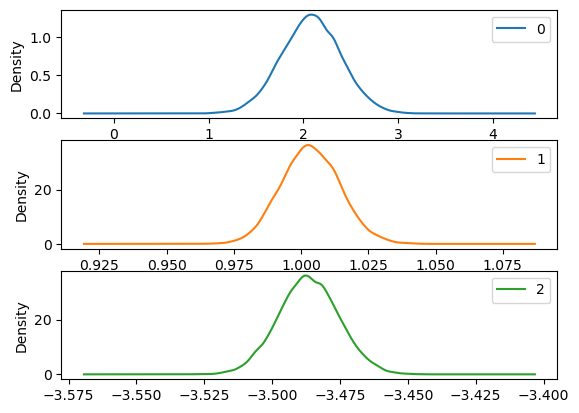

In [55]:
pd.DataFrame(baye_lr.beta_samples).plot.kde(subplots=True,sharex=False)
plt.show()

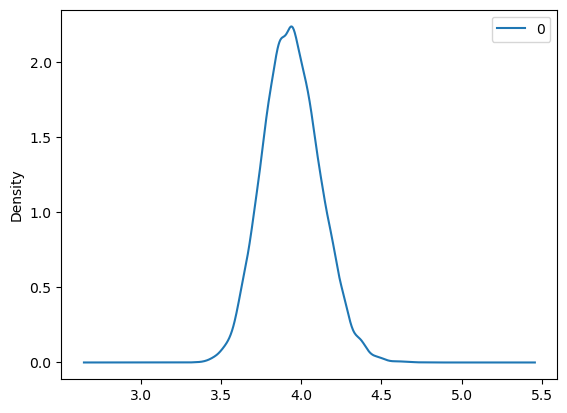

In [56]:
pd.DataFrame(baye_lr.sigma2_samples).plot.kde(subplots=True,sharex=False)
plt.show()

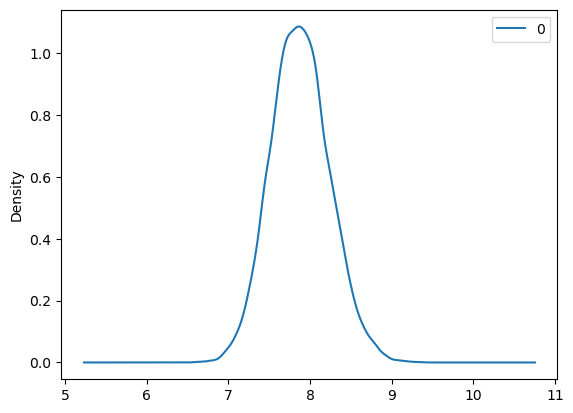

In [57]:
pd.DataFrame(baye_lr.mse_samples(X, y)).plot.kde(subplots=True,sharex=False)
plt.show()

In [29]:
baye_lr.mse_mean(X, y)

Array(3.9722333, dtype=float32)

In [30]:
def generate_rotated_ellipse_data(key, n=500, a=2.0, b=1.0, theta=0.5, noise=0.05):

    key_X, key_flip = jax.random.split(key)

    X = jax.random.uniform(key_X, (n, 2), minval=-3.0, maxval=3.0)

    # Rotación
    R = jnp.array([
        [jnp.cos(theta), -jnp.sin(theta)],
        [jnp.sin(theta),  jnp.cos(theta)]
    ])

    X_rot = X @ R

    ellipse_val = (X_rot[:, 0]**2)/(a**2) + (X_rot[:, 1]**2)/(b**2)
    y = (ellipse_val <= 1.0).astype(jnp.float32)

    flip_mask = jax.random.bernoulli(key_flip, p=noise, shape=(n,))
    y = jnp.where(flip_mask, 1 - y, y)

    return X, y

In [31]:
X, y = generate_rotated_ellipse_data(random.PRNGKey(18081997), n=2000, noise=0.05)

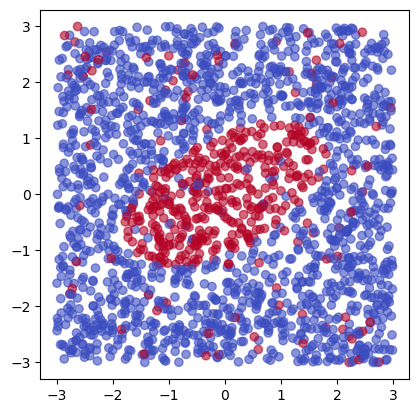

In [32]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", alpha=0.6)
plt.gca().set_aspect('equal')
plt.show()

In [33]:
def bnn_model(X, y=None, hidden_dim=10, tau=1.0):

    n, d = X.shape

    # -------------------------
    # Priors
    # -------------------------
    W1 = numpyro.sample("W1", dist.Normal(0, tau).expand([d, hidden_dim]))
    b1 = numpyro.sample("b1", dist.Normal(0, tau).expand([hidden_dim]))

    W2 = numpyro.sample("W2", dist.Normal(0, tau).expand([hidden_dim]))
    b2 = numpyro.sample("b2", dist.Normal(0, tau))

    # -------------------------
    # Forward
    # -------------------------
    a = jnp.tanh(jnp.dot(X, W1) + b1)
    logits = jnp.dot(a, W2) + b2

    # -------------------------
    # Likelihood
    # -------------------------
    numpyro.sample("target", dist.Bernoulli(logits=logits), obs=y)

In [34]:
kernel = NUTS(bnn_model)
mcmc = MCMC(kernel, num_warmup=2000, num_samples=5000, num_chains=3, chain_method="parallel")

rng_key = random.PRNGKey(0)
mcmc.run(rng_key, X=X, y=y)


  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

  0%|          | 0/7000 [00:00<?, ?it/s]

In [35]:
samples = mcmc.get_samples()

In [36]:
def predict_proba(samples, X):

    W1 = samples["W1"]
    b1 = samples["b1"]
    W2 = samples["W2"]
    b2 = samples["b2"]

    a = jnp.tanh(jnp.matmul(X[None, :, :], W1) + b1[:, None, :])
    logits = jnp.matmul(a, W2[:, :, None]).squeeze(-1) + b2[:, None]

    probs = jax.nn.sigmoid(logits)

    return probs

In [37]:
probs = predict_proba(samples, X)

mean_probs = probs.mean(axis=0)
y_pred = (mean_probs >= 0.5)

accuracy = (y_pred == y).mean()

In [38]:
accuracy

Array(0.93750006, dtype=float32)

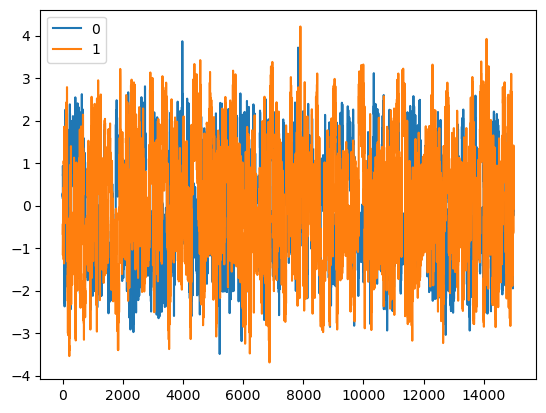

In [39]:
pd.DataFrame(samples['W1'][:, :, 2]).plot()
plt.show()

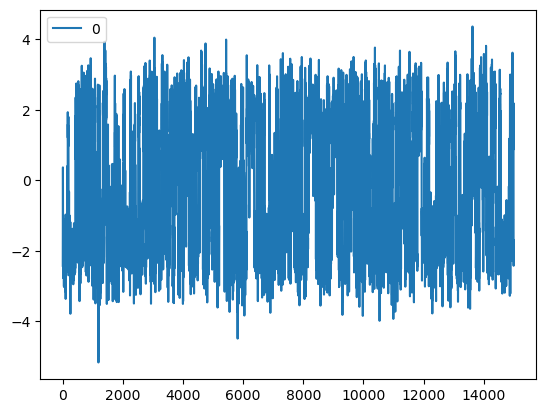

In [40]:
pd.DataFrame(samples['b1'][:,8]).plot()
plt.show()

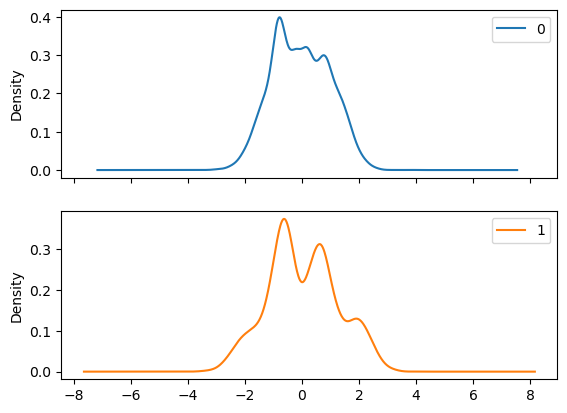

In [41]:
pd.DataFrame(samples['W1'][:, :, 2]).plot.kde(subplots=True)
plt.show()

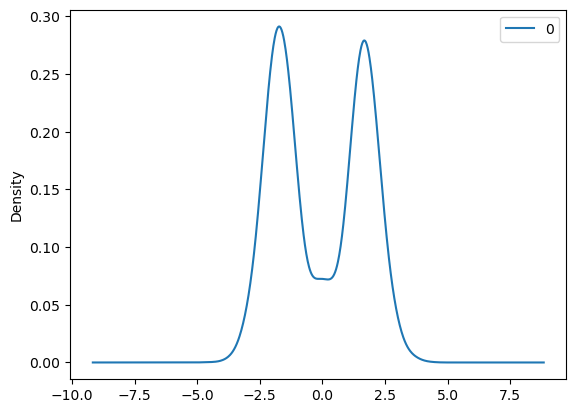

In [101]:
pd.DataFrame(samples['b1'][:, 6]).plot.kde(subplots=True)
plt.show()